# Lezione 5 - Esercizio 1

Text(0, 0.5, 'Frequency')

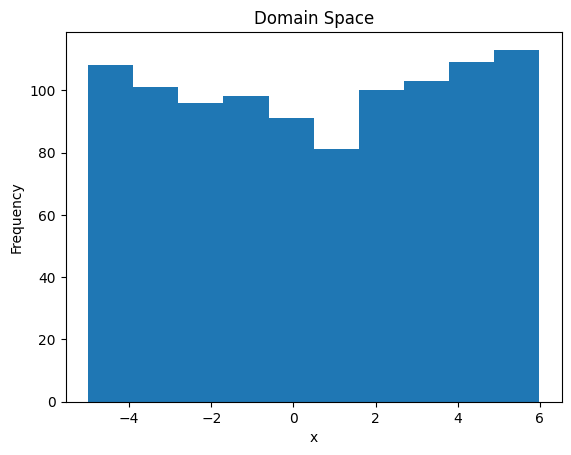

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from hyperopt import fmin,hp,tpe,Trials,rand,pyll

def f(x):
    poly =  np.poly1d([1, -2, -28, 28, 12, -26, 100]) 
    return poly(x) * 0.05

space = hp.uniform('x', -5, 6)
plt.hist([pyll.stochastic.sample(space) for _ in range(1000)])
plt.title('Domain Space')
plt.xlabel('x')
plt.ylabel('Frequency')

In [28]:
tpe_trials = Trials()
tpe_best = fmin(fn=f, space=space, algo=tpe.suggest, trials=tpe_trials, max_evals=200)

print(tpe_best)

100%|██████████| 200/200 [00:00<00:00, 1285.38trial/s, best loss: -219.7983839443517]
{'x': np.float64(4.882787345873199)}


Text(0, 0.5, 'y')

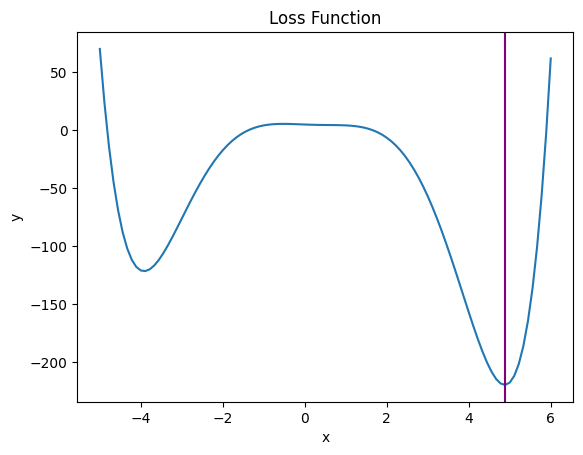

In [29]:
x = np.linspace(-5, 6, 100)
plt.plot(x, f(x))
plt.axvline(tpe_best['x'], color='purple')
plt.title('Loss Function')
plt.xlabel('x')
plt.ylabel('y')
# Trova la posizione del minimo, lavora come un gradiente

Adesso possiamo vedere quanto ci impeiga ogni metodo a trovre un minimo

Text(0, 0.5, 'Frequency')

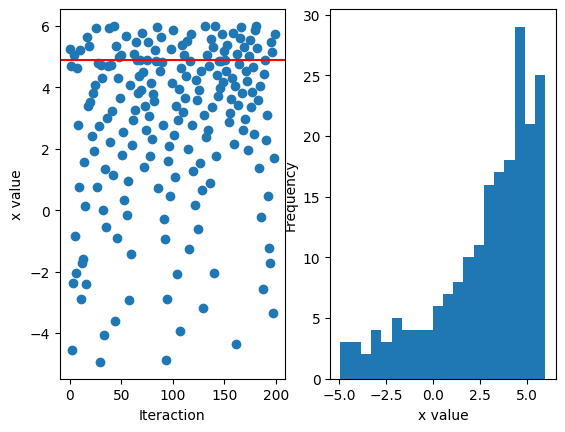

In [32]:
_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(tpe_trials.idxs_vals[0]['x'], # passo epoche 
            tpe_trials.idxs_vals[1]['x']) # e valori
ax1.axhline(tpe_best['x'], color='red')
ax1.set_xlabel('Iteraction')
ax1.set_ylabel('x value')

ax2.hist(tpe_trials.idxs_vals[1]['x'], bins=20)
ax2.set_xlabel('x value')
ax2.set_ylabel('Frequency')

Proviamo con random trials

100%|██████████| 2000/2000 [00:01<00:00, 1078.91trial/s, best loss: -219.79918592856177]
{'x': np.float64(4.8741851506299465)}


Text(0, 0.5, 'Frequency')

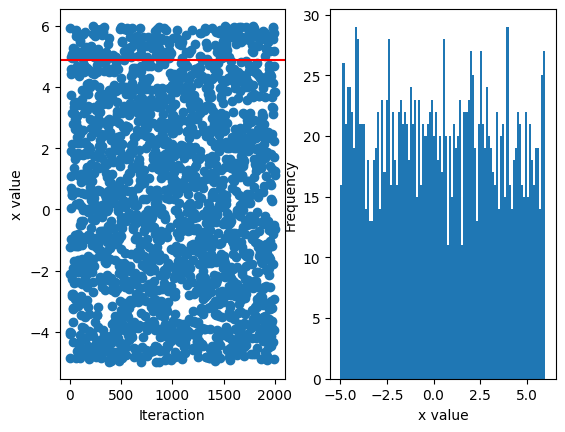

In [15]:
rdn_trials = Trials()
rdn_best = fmin(fn=f, space=space, algo=rand.suggest, trials=rdn_trials, max_evals=2000)

print(rdn_best)

_, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(rdn_trials.idxs_vals[0]['x'], # passo epoche 
            rdn_trials.idxs_vals[1]['x']) # e valori
ax1.axhline(rdn_best['x'], color='red')
ax1.set_xlabel('Iteraction')
ax1.set_ylabel('x value')

ax2.hist(rdn_trials.idxs_vals[1]['x'], bins=100)
ax2.set_xlabel('x value')
ax2.set_ylabel('Frequency')